<h1 style="color:#1f77b4; font-family:'Times New Roman';">
<b>DBSCAN on the Mall Customers Data</b>
</h1>
<div style="font-family:'Times New Roman';">
<b>Goal:</b>
<ol>
<li>Use DBSCAN on a real dataset instead of made up shapes</li>
<li>Group customers using their annual income and spending score</li>
<li>Let DBSCAN flag the unusual customers as noise</li>
<li>Compare the segments with what K-Means gives on the same data</li>
</ol>
Till now i tested DBSCAN on toy shapes like moons and circles. Now lets try a real dataset, the Mall Customers data, the same one i used in the K-Means folder. Every row is a customer with their annual income and a spending score from 1 to 100. A shop would want to group similar customers together for marketing, and the nice thing is DBSCAN can also point out the odd customers that do not fit into any group.
</div>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN, KMeans

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Loading the data</b>
</h2>
<div style="font-family:'Times New Roman';">
This is the same Mall Customers file from the K-Means folder. It has 200 customers and a few columns, but for clustering i will only use the annual income and the spending score.
</div>

In [2]:
df = pd.read_csv("Mall_Customers.csv")
print("Shape:", df.shape)
df.head()

Shape: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Picking the two features</b>
</h2>
<div style="font-family:'Times New Roman';">
Just like in the K-Means notebook i take the Annual Income and the Spending Score columns. Using only two features also makes it easy to plot everything on a normal 2d scatter.
</div>

Feature shape: (200, 2)


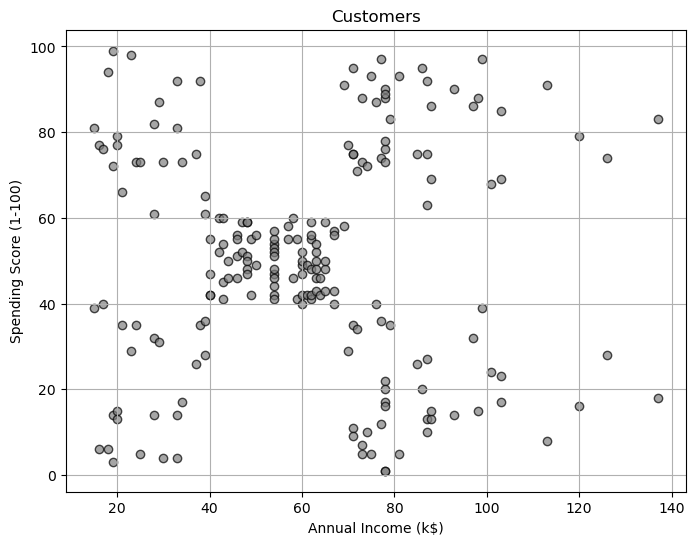

In [3]:
X = df[["Annual Income (k$)", "Spending Score (1-100)"]].values
print("Feature shape:", X.shape)

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], color='gray', edgecolors='k', alpha=0.7)
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customers")
plt.grid(True)
plt.show()

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>A quick note on scaling</b>
</h2>
<div style="font-family:'Times New Roman';">
DBSCAN works with distances so usually we should standardize the features first. Here the income runs from about 15 to 137 and the spending score from 1 to 99, so they are already on a pretty similar range. To keep it simple and to match the K-Means notebook i will use the columns as they are, and the eps value will just be in these same units.
</div>

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Running DBSCAN</b>
</h2>
<div style="font-family:'Times New Roman';">
I will use eps 7.5 and min_pts 5. So a customer needs at least 5 other customers sitting within a distance of 7.5 (in income and score units) around it to count as being in a dense area.
</div>

In [4]:
eps = 7.5
min_pts = 5

db_labels = DBSCAN(eps=eps, min_samples=min_pts).fit_predict(X)

n_clusters = len(set(db_labels) - {-1})
n_noise = np.sum(db_labels == -1)

print("Segments found:", n_clusters)
print("Noise customers:", n_noise)

Segments found: 7
Noise customers: 35


<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Plotting the segments</b>
</h2>
<div style="font-family:'Times New Roman';">
Lets look at the segments DBSCAN found. The black crosses are the noise customers, the ones that did not fall into any dense group.
</div>

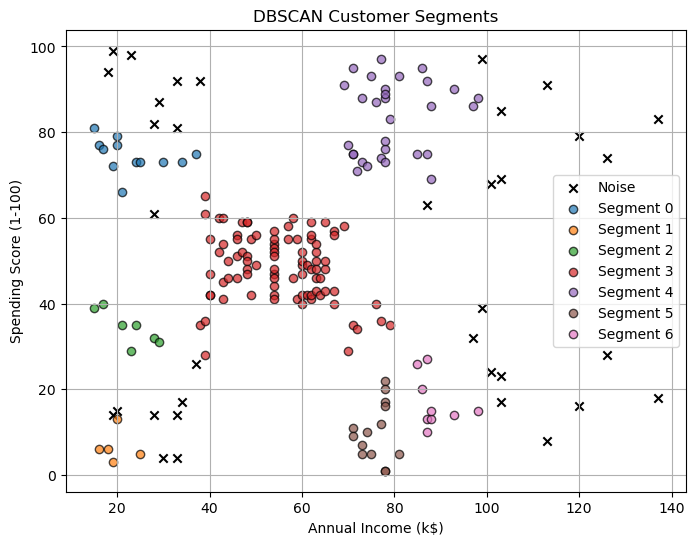

In [5]:
plt.figure(figsize=(8, 6))

for lab in sorted(set(db_labels)):
    mask = db_labels == lab
    if lab == -1:
        plt.scatter(X[mask, 0], X[mask, 1], c='black', marker='x', label='Noise')
    else:
        plt.scatter(X[mask, 0], X[mask, 1], edgecolors='k', alpha=0.7, label=f'Segment {lab}')

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("DBSCAN Customer Segments")
plt.legend()
plt.grid(True)
plt.show()

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>What do the segments mean?</b>
</h2>
<div style="font-family:'Times New Roman';">
Each dense blob is a kind of customer. The corners are the interesting ones, like low income but high spending, or high income but low spending. The big group in the middle is the average customer with normal income and normal spending. And the noise customers are the in between people who do not clearly belong to any group, which is actually useful to know on its own.
</div>

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Comparing with K-Means</b>
</h2>
<div style="font-family:'Times New Roman';">
In the K-Means folder i ran K-Means with k=5 on this exact data. The big difference is K-Means has to put every single customer into one of the 5 groups, even the weird ones. DBSCAN instead keeps the odd customers aside as noise. Lets put them next to each other.
</div>

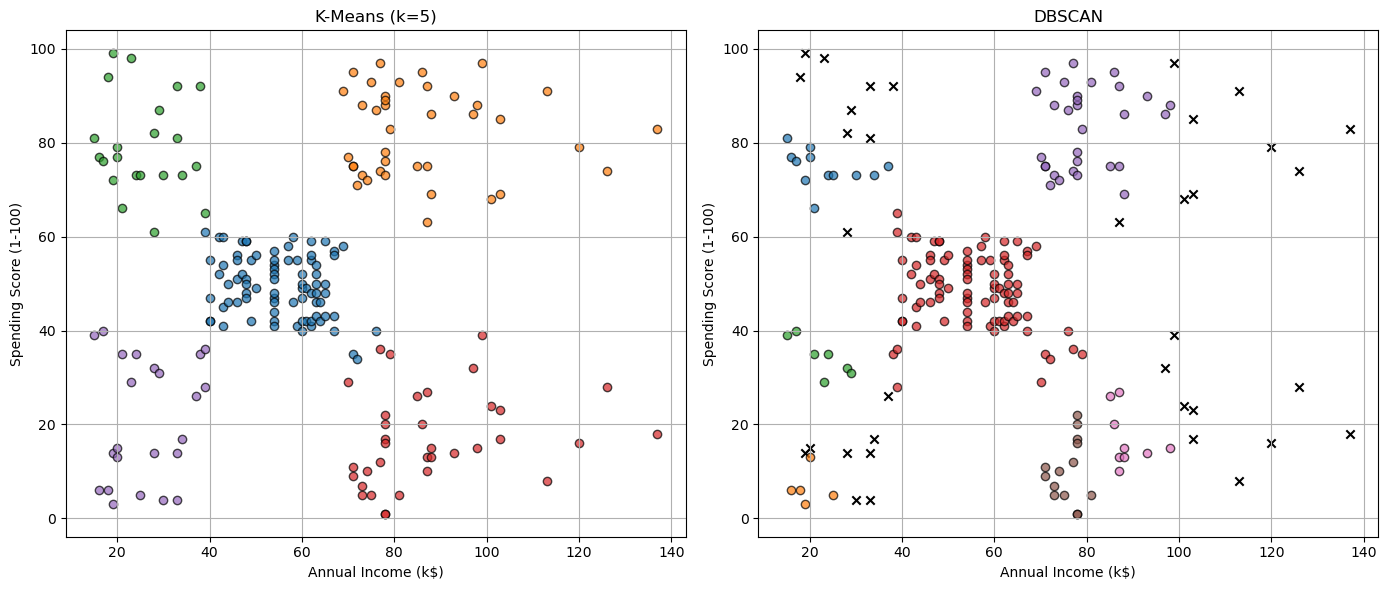

K-Means put all 200 customers into 5 groups, with no outliers left out
DBSCAN found 7 segments and set aside 35 customers as noise


In [6]:
# small helper so i do not repeat the plotting code
def plot_segments(ax, X, labels, title):
    for lab in sorted(set(labels)):
        mask = labels == lab
        if lab == -1:
            ax.scatter(X[mask, 0], X[mask, 1], c='black', marker='x', label='Noise')
        else:
            ax.scatter(X[mask, 0], X[mask, 1], edgecolors='k', alpha=0.7, label=f'Group {lab}')
    ax.set_xlabel("Annual Income (k$)")
    ax.set_ylabel("Spending Score (1-100)")
    ax.set_title(title)
    ax.grid(True)

km_labels = KMeans(n_clusters=5, random_state=42, n_init=10).fit_predict(X)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_segments(axes[0], X, km_labels, "K-Means (k=5)")
plot_segments(axes[1], X, db_labels, "DBSCAN")
plt.tight_layout()
plt.show()

print("K-Means put all", len(X), "customers into 5 groups, with no outliers left out")
print("DBSCAN found", n_clusters, "segments and set aside", n_noise, "customers as noise")

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Summary</b>
</h2>
<div style="font-family:'Times New Roman';">
<ul>
<li>Used DBSCAN on the real Mall Customers data with annual income and spending score</li>
<li>DBSCAN found several customer segments on its own without me choosing the number</li>
<li>It also flagged the unusual customers as noise instead of forcing them into a group</li>
<li>K-Means on the same data put all 200 customers into exactly 5 groups, outliers included</li>
<li>So DBSCAN is handy when you also care about spotting the customers who do not fit any pattern</li>
</ul>
This is the real data version of DBSCAN. Together with the moons and circles notebooks it shows DBSCAN both on clean shapes and on actual messy data.
</div>